In [2]:
!pip install torch torchvision torchmetrics matplotlib tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.0 MB/s eta 0:00:00


In [3]:
import torch
import torchvision

import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import random_split

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

Dispositivo: cuda


In [5]:
dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="segmentation",
    download=True
)

print("Quantidade de imagens:", len(dataset))

100%|██████████| 792M/792M [00:38<00:00, 20.6MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 6.95MB/s]


Quantidade de imagens: 3680


Imagem: (394, 500)
Máscara: (394, 500)


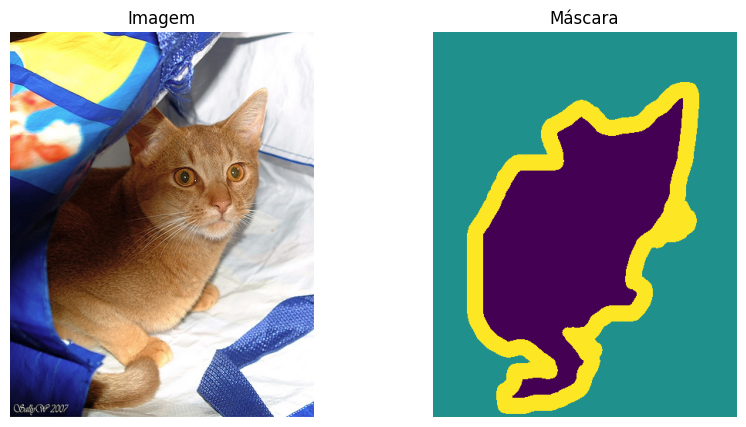

In [6]:
image, mask = dataset[0]

print("Imagem:", image.size)
print("Máscara:", mask.size)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Imagem")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Máscara")
plt.axis("off")

plt.show()

In [7]:
image, mask = dataset[0]

mask_np = np.array(mask)

print("Valores únicos encontrados:")
print(np.unique(mask_np))

Valores únicos encontrados:
[1 2 3]


In [8]:
from torchvision import transforms
from PIL import Image
import torch
import numpy as np

In [9]:
IMAGE_SIZE = 128

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

mask_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=Image.NEAREST
    ),
])

In [10]:
from torch.utils.data import Dataset

class PetSegmentationDataset(Dataset):

    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, mask = self.dataset[idx]

        image = image_transform(image)

        mask = mask_transform(mask)
        mask = np.array(mask)

        # Classes:
        # 1 = fundo
        # 2 = pet
        # 3 = contorno

        mask = torch.tensor(mask, dtype=torch.long)

        mask = mask - 1

        return image, mask

In [11]:
full_dataset = PetSegmentationDataset(dataset)

print("Total:", len(full_dataset))

Total: 3680


In [12]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

Treino: 2576
Validação: 552
Teste: 552


In [13]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders criados!")

DataLoaders criados!


In [14]:
images, masks = next(iter(train_loader))

print("Imagens:", images.shape)
print("Máscaras:", masks.shape)

print("Classes da máscara:")
print(torch.unique(masks))

Imagens: torch.Size([8, 3, 128, 128])
Máscaras: torch.Size([8, 128, 128])
Classes da máscara:
tensor([0, 1, 2])


In [15]:
import torch.nn as nn

In [16]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [17]:
class UNet(nn.Module):

    def __init__(self, n_classes=3):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.up1 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )

        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(128, 64)

        self.final = nn.Conv2d(
            64,
            n_classes,
            kernel_size=1
        )

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        bridge = self.bridge(p2)

        u1 = self.up1(bridge)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.conv2(u2)

        return self.final(u2)

In [18]:
model = UNet(n_classes=3).to(device)

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bridge): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  

In [19]:
images, masks = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Entrada :", images.shape)
print("Saída :", outputs.shape)

Entrada : torch.Size([8, 3, 128, 128])
Saída : torch.Size([8, 3, 128, 128])


In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Configuração concluída!")

Configuração concluída!


In [21]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

loss = criterion(outputs, masks)

print("Loss:", loss.item())

Loss: 1.0951915979385376


In [22]:
from tqdm import tqdm

In [23]:
def train_one_epoch(model, dataloader, optimizer, criterion):

    model.train()

    running_loss = 0

    for images, masks in tqdm(dataloader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

In [24]:
def validate_one_epoch(model, dataloader, criterion):

    model.eval()

    running_loss = 0

    with torch.no_grad():

        for images, masks in dataloader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_loss += loss.item()

    return running_loss / len(dataloader)

In [25]:
EPOCHS = 10

train_losses = []
val_losses = []

In [26]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

100%|██████████| 322/322 [00:33<00:00,  9.52it/s]


Epoch [1/10] Train Loss: 0.8324 Val Loss: 0.7055


100%|██████████| 322/322 [00:33<00:00,  9.58it/s]


Epoch [2/10] Train Loss: 0.7007 Val Loss: 0.6852


100%|██████████| 322/322 [00:34<00:00,  9.42it/s]


...

Epoch [8/10] Train Loss: 0.4906 Val Loss: 0.4941


100%|██████████| 322/322 [00:34<00:00,  9.34it/s]


Epoch [9/10] Train Loss: 0.4668 Val Loss: 0.4537


100%|██████████| 322/322 [00:34<00:00,  9.31it/s]


Epoch [10/10] Train Loss: 0.4537 Val Loss: 0.4562


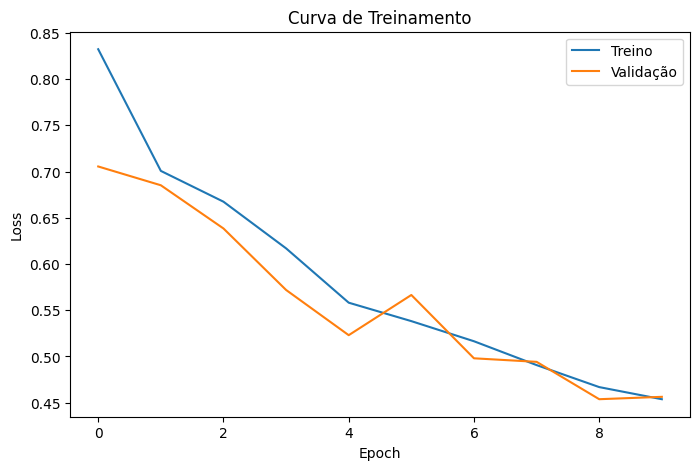

In [27]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Treino")
plt.plot(val_losses, label="Validação")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Curva de Treinamento")

plt.legend()

plt.show()

In [28]:
!pip install torchmetrics -q

In [29]:
from torchmetrics.classification import MulticlassAccuracy
from torchmetrics.segmentation import MeanIoU

In [30]:
accuracy_metric = MulticlassAccuracy(
    num_classes=3
).to(device)

iou_metric = MeanIoU(
    num_classes=3
).to(device)

In [31]:
model.eval()

accuracy_metric.reset()
iou_metric.reset()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        accuracy_metric.update(preds, masks)
        iou_metric.update(preds, masks)

accuracy = accuracy_metric.compute()
iou = iou_metric.compute()

print("Accuracy:", accuracy.item())
print("IoU:", iou.item())

Accuracy: 0.7265747785568237
IoU: 0.6416969895362854


In [32]:
model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

preds = torch.argmax(outputs, dim=1)

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

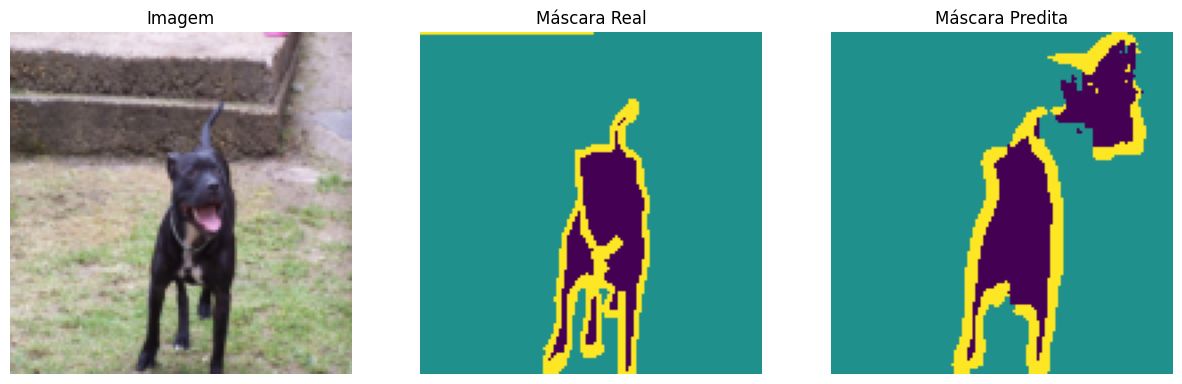

In [33]:
sample = 0

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(images[sample].permute(1,2,0))
plt.title("Imagem")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masks[sample])
plt.title("Máscara Real")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(preds[sample])
plt.title("Máscara Predita")
plt.axis("off")

plt.show()

In [34]:
torch.save(
    model.state_dict(),
    "unet_pet_segmentation.pth"
)

print("Modelo salvo!")

Modelo salvo!


In [35]:
torch.save(model.state_dict(), "unet_pet_segmentation.pth")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [36]:
from google.colab import files

files.download("unet_pet_segmentation.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>